In [8]:
import pandas as pd

In [40]:
# Configures pandas to display more columns without wrapping
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.width', 1000)
pd.set_option('display.max_colwidth', 25) # Shows only first 25 characters
pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.float_format', '{:.2f}'.format)

In [42]:
# Load just the first few rows to see structure
customers_sample = pd.read_csv('../data/raw/customers.csv', nrows=5)

print("Column names:")
print(customers_sample.columns.tolist())
print("\nFirst few rows:")
print(customers_sample)
print("\nData types:")
print(customers_sample.dtypes)

Column names:
['customer_id', 'FN', 'Active', 'club_member_status', 'fashion_news_frequency', 'age', 'postal_code']

First few rows:
                customer_id   FN  Active club_member_status fashion_news_frequency  age               postal_code
0  00000dbacae5abe5e2388...  NaN     NaN             ACTIVE                   NONE   49  52043ee2162cf5aa7ee79...
1  0000423b00ade91418cce...  NaN     NaN             ACTIVE                   NONE   25  2973abc54daa8a5f8ccfe...
2  000058a12d5b43e67d225...  NaN     NaN             ACTIVE                   NONE   24  64f17e6a330a85798e499...
3  00005ca1c9ed5f5146b52...  NaN     NaN             ACTIVE                   NONE   54  5d36574f52495e81f019b...
4  00006413d8573cd20ed71... 1.00    1.00             ACTIVE              Regularly   52  25fa5ddee9aac01b35208...

Data types:
customer_id                object
FN                        float64
Active                    float64
club_member_status         object
fashion_news_frequency     object


In [62]:
# Better pandas display settings
pd.options.display.float_format = '{:.2f}'.format

# Load data
customers = pd.read_csv('../data/raw/customers.csv')

# Clean, readable output
print("="*60)
print("H&M CUSTOMER AGE OVERVIEW")
print("="*60)

print(f"\n📊 SAMPLE SIZE")
print(f"   Total Customers:        {len(customers):>10,}")
print(f"   With Age Data:          {customers['age'].notna().sum():>10,}")
print(f"   Missing Age:            {customers['age'].isna().sum():>10,} ({customers['age'].isna().sum()/len(customers)*100:.1f}%)")

print(f"\n🎂 AGE STATISTICS")
print(f"   Minimum Age:            {customers['age'].min():>10.0f} years")
print(f"   25th Percentile:        {customers['age'].quantile(0.25):>10.0f} years")
print(f"   Median Age:             {customers['age'].median():>10.0f} years")
print(f"   Mean Age:               {customers['age'].mean():>10.1f} years")
print(f"   75th Percentile:        {customers['age'].quantile(0.75):>10.0f} years")
print(f"   Maximum Age:            {customers['age'].max():>10.0f} years")
print(f"   Standard Deviation:     {customers['age'].std():>10.1f} years")
print(f"   Unique Ages:            {customers['age'].nunique():>10.0f} ")
print("="*60)

H&M CUSTOMER AGE OVERVIEW

📊 SAMPLE SIZE
   Total Customers:         1,371,980
   With Age Data:           1,356,119
   Missing Age:                15,861 (1.2%)

🎂 AGE STATISTICS
   Minimum Age:                    16 years
   25th Percentile:                24 years
   Median Age:                     32 years
   Mean Age:                     36.4 years
   75th Percentile:                49 years
   Maximum Age:                    99 years
   Standard Deviation:           14.3 years
   Unique Ages:                    84 


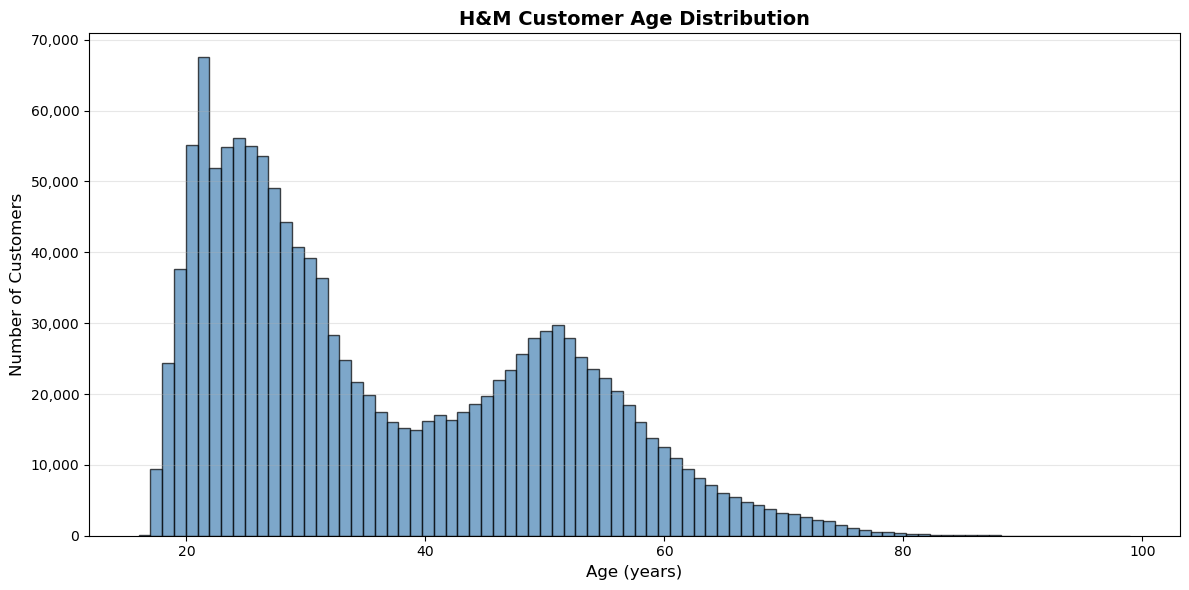

In [64]:
import matplotlib.pyplot as plt

# Clean the age data
ages_clean = customers['age'].dropna()

# Create the histogram
plt.figure(figsize=(12, 6))
plt.hist(ages_clean, bins=84, edgecolor='black', alpha=0.7, color='steelblue')
plt.xlabel('Age (years)', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.title('H&M Customer Age Distribution', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

# Format y-axis with commas
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

plt.tight_layout()
plt.show()

In [72]:
from scipy.signal import find_peaks

# Get age counts sorted by age (not by count)
age_counts = ages_clean.value_counts().sort_index()

# Find peaks (local maxima)
peaks, properties = find_peaks(age_counts.values, prominence=1000)

# Get the ages corresponding to those peaks
peak_ages = age_counts.index[peaks]
peak_counts = age_counts.values[peaks]

print(f"Found {len(peak_ages)} peaks:")
for age, count in zip(peak_ages, peak_counts):
    print(f"  Age {age}: {count:,} customers")

Found 3 peaks:
  Age 21.0: 67,530 customers
  Age 24.0: 56,124 customers
  Age 51.0: 29,720 customers


✅ Visualization saved!


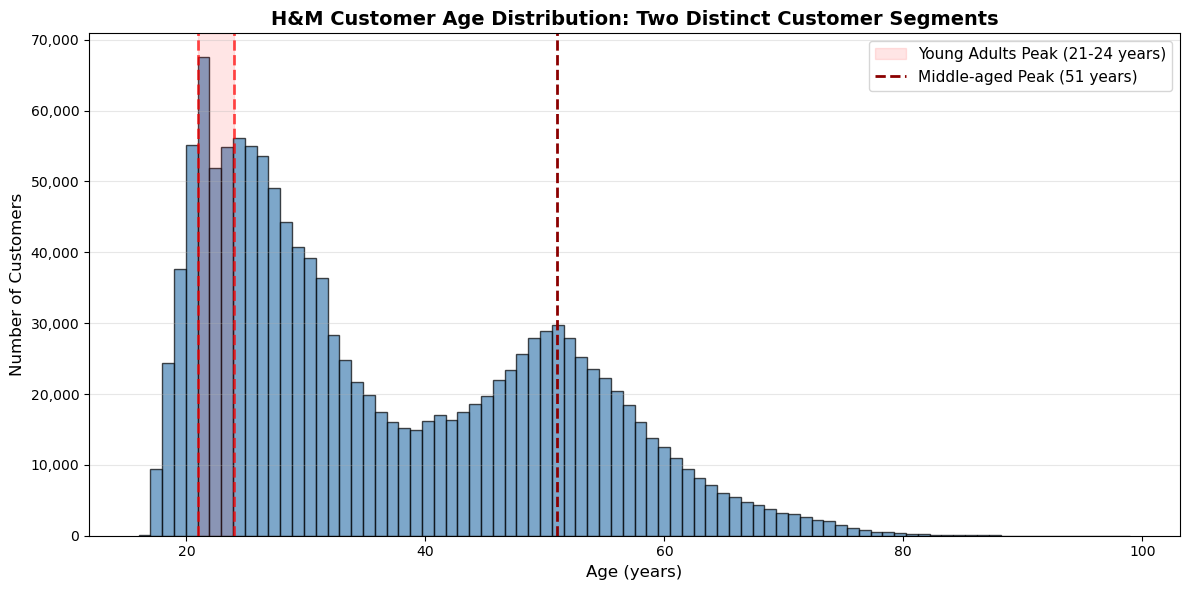

In [76]:
# Create final visualization focusing on the 2 segments
plt.figure(figsize=(12, 6))
plt.hist(ages_clean, bins=84, edgecolor='black', alpha=0.7, color='steelblue')

# Mark the young adult segment (21-24 peak)
plt.axvline(21, color='red', linestyle='--', linewidth=2, alpha=0.7)
plt.axvline(24, color='red', linestyle='--', linewidth=2, alpha=0.7)
plt.axvspan(21, 24, alpha=0.1, color='red', label='Young Adults Peak (21-24 years)')

# Mark the middle-aged segment
plt.axvline(51, color='darkred', linestyle='--', linewidth=2, label='Middle-aged Peak (51 years)')

plt.xlabel('Age (years)', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.title('H&M Customer Age Distribution: Two Distinct Customer Segments', fontsize=14, fontweight='bold')
plt.legend(fontsize=11, loc='upper right')
plt.grid(axis='y', alpha=0.3)

ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('../visualizations/day1_age_distribution.png', dpi=300, bbox_inches='tight')
print("✅ Visualization saved!")
plt.show()

H&M's customer data reveals two clear age peaks: early 20s (ages 21-24) and 
early 50s (age 51), with the younger segment being significantly larger. The 
gap between these peaks is visible, though further analysis comparing against 
general population demographics would be needed to determine if this represents 
a market opportunity or simply reflects demographic realities.